In [ ]:
"""
Regularization simplifies the minimization of complex models

As per Prof. Wu, you add a constrain to the minimization function
in order to retrieve a simpler model for your targets

We will go over some common types of Regularization

Youtube link: https://www.youtube.com/watch?v=1HFmdaZIZbA&list=PLdk2fd27CQzQCoOj0YfBd4ECr76EqEXz4&index=16
"""

In [ ]:
"""
3 most Common constraints

Lasso: Add the L1 norm of your weights to the min function

Ridge Regression: Add the L2 norm squared of ur weights to the min function

Elastic Net: Combination of both above

The idea is, when you add the norm of your weights,
the min func is trying to minimize the weights and the errors,
this results in an answer that has proportionately small weights and errors

"""

In [16]:
import numpy as np
from scipy.integrate import quad
from scipy.optimize import approx_fprime
import matplotlib.pyplot as plt

In [ ]:
"""
Below are the cost functions for a lasso and ridge model
Followed by their derivatives

The lambda * norm parts of the function are penalties = constrains = regularizer
"""

In [ ]:
def lasso_cost(w, Phi, y, lam):
    """Here we are defining the function we want to minimize to achieve our optimal model
        Lasso uses the l1 norm of our weights as a regularizer """
    residuals = (Phi @ w) - y # The error for each data point
    return 0.5 * np.sum(residuals ** 2) + lam * np.sum(np.abs(w)) # end is L1 norm

In [ ]:
def lasso_gradient(w, Phi, y, lam):
    left_side_grad = Phi.T @ (Phi @ w - y) # You transpose T to make dimensions fit
    right_side_grad = lam * np.sign(w)

    return left_side_grad + right_side_grad

In [ ]:
def ridge_cost(w, Phi, y, lam): # Same as lasso_cost but for ridge (l2_norm^2)
    residuals = (Phi @ w) - y # The error for each data point
    return 0.5 * np.sum(residuals ** 2) + lam * (np.linalg.norm(w, ord=2))^2

In [ ]:
def ridge_gradient(w, Phi, y, lam):
    left_side_grad = Phi.T @ (Phi @ w - y)
    right_side_grad = lam * w
    return left_side_grad + right_side_grad

In [ ]:
"""
L1 norm is best for pushing non-important features to 0
L2 norm is more accurate but may have more complex feature weights

This is why elastic net is nice, becuase it combines these ideas
We can apply lambda1 and lambda2 to modify how much we care about each

Below we will try to implement Lasso with gradient descent
"""

In [12]:
data = np.array([[0, 0], [1, 1], [2, 1], [3, 2]])
X = data[:, 0]
y = data[:, 1]

w0 = np.array([0, 0, 1])
Phi = np.column_stack([X**2, X, np.ones_like(X)])

lam = 0.2
eta = 0.01

print(Phi)

[[0 0 1]
 [1 1 1]
 [4 2 1]
 [9 3 1]]


Best w = [0.08997063 0.3353444  0.13735537]
With an error of 0.2327942731922386


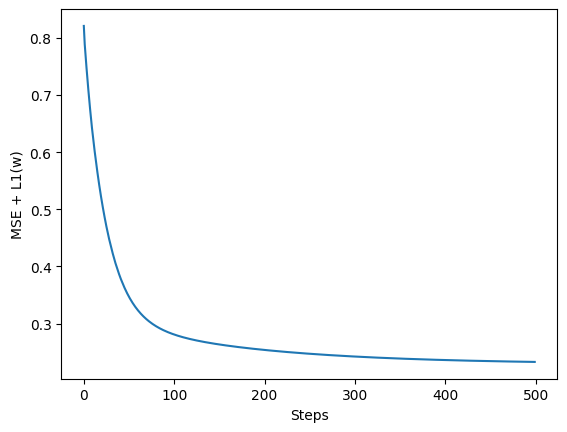

In [29]:
def min_lasso(w0, Phi, y, lam, eta=0.1, steps=20):

    eta = eta
    value_list = []
    w = w0
    for i in range(steps):
        w_prime = lasso_gradient(w, Phi, y, lam)
        w = w - eta * w_prime
        value_list.append(lasso_cost(w, Phi, y, lam))

    print(f"Best w = {w}")
    print(f"With an error of {value_list[steps-1]}")

    plt.plot(value_list)
    plt.xlabel('Steps')
    plt.ylabel('MSE + L1(w)')
    plt.show()

    return w

w = min_lasso(w0, Phi, y, lam, eta=eta, steps=500)

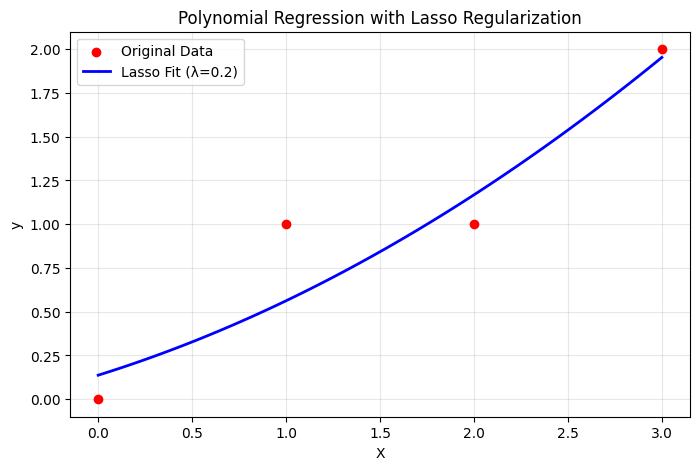

In [30]:
# Plotting the line we found in our gradient descent
# 1. Generate smooth x-values for the curve
x_range = np.linspace(0, 3, 100)

# 2. Create the Phi matrix for these new points (must match your 3 columns)
Phi_plot = np.column_stack([x_range**2, x_range, np.ones_like(x_range)])

# 3. Calculate the predicted y values using your final 'w'
# Remember: y = Phi @ w
y_plot = Phi_plot @ w

# 4. Create the visual comparison
plt.figure(figsize=(8, 5))
plt.scatter(X, y, color='red', label='Original Data', zorder=5)
plt.plot(x_range, y_plot, label=f'Lasso Fit (λ={lam})', color='blue', linewidth=2)

plt.title("Polynomial Regression with Lasso Regularization")
plt.xlabel("X")
plt.ylabel("y")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

In [ ]:
"""
Below is example code from Prof. Wu
This contains more complex 1 feature optimization/modeling/regression
"""

In [40]:
import wplotlib
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import Lasso
from sklearn.linear_model import Ridge

In [71]:
X = np.array([ [1, 1],
               [2, 1],
               [1, 1],
               [3, 1],
               [2, 1],
               [6, 1],
               [2, 1],
               [0, 1],
               [1, 1],
               [1, 1]])
w = np.array([[3], [2]])
y = X.dot(w) + np.random.randn(10, 1)

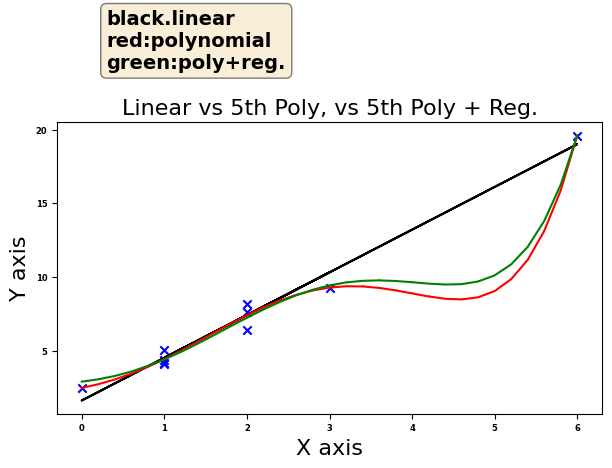

In [74]:
""" Below we compute standard LinReg (LR), 5th poly LR, and 5th poly + L2 penalty (ridge) LR

    For the second two LR's after we fit we create fake data to better plot our models/lines of best fit

    wplotlib is a library created by Prof. Wu to better show our data
"""

linR = LinearRegression().fit(X, y) # Training a standard y = ax1 + bx2 + c model on the data
y_pred = linR.predict(X) # Generates this straight line prediction for the X vals

p = wplotlib.lines(X[:,0], y_pred, color='black', show=False) # Plots the pred: x-axis = 1st X only

# ------------------------------------------------------------------------------------------------

poly = PolynomialFeatures(5) # poly will generate x^2, x^3... x^5 for our features in X
newX = poly.fit_transform(X) # Takes  2 features and makes all possible combos for x^1 -> x^5 (21 total)
# This is because you have x^2, x^5 but also x1^2,x2^5... and so on because we have two features

linR = LinearRegression().fit(newX, y) # Training a new model with our 10 features (5th deg poly)

X2 = np.arange(0, 6.2, 0.2).reshape(31, 1) # |
X2 = np.hstack((X2, np.ones((31, 1))))     # | 3 lines create phantom data and predictions to plot
X3 = poly.fit_transform(X2)                # | For 0.2 increments in our X range so we can plot smoothly

y_pred = linR.predict(X3)   # Predicting y for the fake points created above, used for our graph

q = wplotlib.lines(X2[:,0], y_pred, color='red', show=False)

# -------------------------------------------------------------------------------------------------

linR = Ridge(5).fit(newX, y) # The value in the ridge () is the lambda for our L2^2 penalty
X2 = np.arange(0, 6.2, 0.2).reshape(31, 1)
X2 = np.hstack((X2, np.ones((31, 1))))
X3 = poly.fit_transform(X2)
y_pred = linR.predict(X3)

wplotlib.lines(X2[:,0], y_pred, color='green', show=False)
wplotlib.scatter(X[:,0], y, 'Linear vs 5th Poly, vs 5th Poly + Reg.', 'X axis', 'Y axis',
                imgText='black.linear\nred:polynomial\ngreen:poly+reg.', yTextShift=1.5,
                ticker_fontsize=6, show=False)

p.show()


In [ ]:
"""
The goal of the following is to identify idea lambda values in our regular LR process

Using our Stock prediction data from Prof. Wu github we will...
Steps
1. Read data
2. Sort, Categorize, and Prep data
3. Preprocess Data
4. Retrieve our phi/transform data into nth order polynomial etc...
5. Apply a lasso or ridge constraint
6. Use Train-Test-Validate to identify optimal lambda
"""

In [77]:
# Read in Data and categorize

import pandas as pd

prediction_df = pd.read_csv('stock_prediction_data.csv', header=None)
price_df = pd.read_csv('stock_price.csv', header=None)

X = prediction_df
y = price_df

print(prediction_df.head(2))
print(price_df.head(2))

      0     1     2     3     4     5     6     7     8     9
0  5.23  1.32  2.85  1.99  9.49  2.92  8.09  7.77  1.15  1.49
1  5.92  0.58  6.34  6.21  0.09  4.69  0.16  3.97  2.35  2.71
       0
0  -0.31
1 -16.86


In [84]:
# prep/preprocess data

from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
scaled_X = scaler.fit_transform(X)

print(scaled_X[0])
print(scaled_X[1])

[ 0.0389 -1.2143 -0.7146 -1.0895  1.4949 -0.6937  0.9879  0.9527 -1.2199 -1.2628]
[ 0.2814 -1.4695  0.4986  0.399  -1.6414 -0.0941 -1.7631 -0.3437 -0.8092 -0.8413]


In [92]:
# Train/Validate/Test split data

from sklearn.model_selection import train_test_split

# Step 1: split off 80% train, 20% temp (val + test combined)
X_train, X_temp, y_train, y_temp = train_test_split(scaled_X, y, test_size=0.2, random_state=51)

# Step 2: split the 20% temp into 10% val and 10% test (50/50 split of the 20%)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=51)


In [93]:
# 2nd order polynomial Phi with Lasso, Mannualy create func to identify best lam
from sklearn.metrics import mean_squared_error

def second_poly_lasso(X_train, y_train, X_val, y_val, lam):
    poly2 = PolynomialFeatures(2)
    phi = poly2.fit_transform(X_train)
    linR = Lasso(lam).fit(phi, y_train)
    
    X_val_p2 = poly2.fit_transform(X_val)
    y_pred = linR.predict(X_val_p2)

    mse = mean_squared_error(y_val, y_pred)

    return mse

lam = None
mse = np.inf
for i in range(0, 20, 1):
    j = i / 5
    cur_mse = second_poly_lasso(X_train, y_train, X_val, y_val, j)
    if cur_mse < mse:
        lam = j
        mse = cur_mse

print(f'The best Lam to reduce MSE is {lam} with an MSE of {mse}')



The best Lam to reduce MSE is 0.0 with an MSE of 0.07618228696937833


In [99]:
# Industry standard way to identify lambda with Ridge this time

from sklearn.linear_model import RidgeCV

poly2 = PolynomialFeatures(2)
phi_2 = poly2.fit_transform(X_train)

test_lams = [0.0, 0.01, 0.05, 0.1, 0.3, 0.5, 0.75, 1, 1.5, 2, 3, 5, 10]

ridge_cv_model = RidgeCV(alphas=test_lams, cv=5)
ridge_cv_model.fit(phi_2, y_train)

best_lam = ridge_cv_model.alpha_
best_lam


np.float64(0.01)